In [ ]:

# Install COBRApy
!pip install cobra -q

# Import libraries
import cobra
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("✅ COBRApy installed correctly")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.5 MB/s eta 0:00:00
✅ COBRApy installed correctly


In [ ]:
# Install COBRApy
!pip install cobra -q

# Import libraries
import cobra
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("✅ COBRApy installed correctly")

✅ COBRApy installed correctly


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving MODEL1507180068_urn.xml to MODEL1507180068_urn.xml


In [ ]:
import cobra

model = cobra.io.read_sbml_model("MODEL1507180068_urn.xml")

print("✅ Modelo cargado correctamente")
print("Reacciones:", len(model.reactions))
print("Metabolitos:", len(model.metabolites))
print("Genes:", len(model.genes))

✅ Modelo cargado correctamente
Reacciones: 1056
Metabolitos: 911
Genes: 746


In [ ]:
# Step 2: Load the manually downloaded iJN746 metabolic model

import cobra
from google.colab import files

# Upload the SBML file downloaded manually from BioModels
uploaded = files.upload()

# Replace with the exact uploaded filename if different
model_file = "MODEL1507180068_urn.xml"

# Load the SBML model into COBRApy
model = cobra.io.read_sbml_model(model_file)

print("Model loaded successfully")
print(f"Reactions: {len(model.reactions)}")
print(f"Metabolites: {len(model.metabolites)}")
print(f"Genes: {len(model.genes)}")

KeyboardInterrupt: 

In [ ]:
# Basal growth rate
solution = model.optimize()

print(f"Basal growth rate: {solution.objective_value:.4f} h⁻¹")

# Search glycine betaine-related reactions
print("\n Glycine betaine-related reactions:\n")

keywords = ["betaine", "choline", "osmo", "glycine betaine", "bet"]

for rxn in model.reactions:
    for kw in keywords:
        if kw.lower() in rxn.name.lower() or kw.lower() in rxn.id.lower():

            print(f"ID: {rxn.id}")
            print(f"Name: {rxn.name}")
            print(f"Equation: {rxn.reaction}")
            print(f"Bounds: {rxn.bounds}")
            print("---")

            break

Basal growth rate: 3.6794 h⁻¹

 Glycine betaine-related reactions:

ID: BETALDHx
Name: betaine-aldehyde dehydrogenase
Equation: betald_c + h2o_c + nad_c --> glyb_c + 2.0 h_c + nadh_c
Bounds: (0.0, 999999.0)
---
ID: BHMT
Name: betaine-homocysteine S-methyltransferase
Equation: glyb_c + hcys_DASH_L_c --> dmgly_c + met_DASH_L_c
Bounds: (0.0, 999999.0)
---
ID: CHLabcpp
Name: choline transport via ABC system (periplasm)
Equation: atp_c + chol_p + h2o_c --> adp_c + chol_c + h_c + pi_c
Bounds: (0.0, 999999.0)
---
ID: CHLt2pp
Name: choline transport via proton symport (periplasm)
Equation: chol_p + h_p --> chol_c + h_c
Bounds: (0.0, 999999.0)
---
ID: CHLtex
Name: choline transport via diffusion (extracellular to periplasm)
Equation: chol_e <=> chol_p
Bounds: (-999999.0, 999999.0)
---
ID: CHOLD
Name: choline dehydrogenase
Equation: chol_c + nad_c --> betald_c + h_c + nadh_c
Bounds: (0.0, 999999.0)
---
ID: CHOLSH
Name: choline sulphatase
Equation: chols_c + h2o_c --> chol_c + h_c + so4_c
Bounds:

In [ ]:
# Search biomass reaction
print("Searching for biomass reaction:\n")

for rxn in model.reactions:

    if "biomass" in rxn.id.lower() or "biomass" in rxn.name.lower():

        print(f"ID: {rxn.id}")
        print(f"Name: {rxn.name}")
        print("---")

Searching for biomass reaction:

ID: BiomassKT_TEMP
Name: BiomassKT_TEMP (based on Ecoli, arbitrary values for lipids and heme)
---


In [ ]:
with model:

    # Enable choline uptake
    model.reactions.get_by_id("EX_chol_e").lower_bound = -10
    model.reactions.get_by_id("EX_chol_e").upper_bound = 0

    # Set biomass as objective function
    model.objective = "BiomassKT_TEMP"

    # Run optimization
    solution = model.optimize()

    print(f"Status: {solution.status}")
    print(f"Growth rate: {solution.fluxes['BiomassKT_TEMP']:.4f}")

    print(f"Flux EX_chol_e: {solution.fluxes['EX_chol_e']:.4f}")
    print(f"Flux CHOLD (betA): {solution.fluxes['CHOLD']:.4f}")

Status: optimal
Growth rate: 4.5211
Flux EX_chol_e: -10.0000
Flux CHOLD (betA): 10.0000


In [ ]:
results = []

with model:

    # Base configuration
    model.reactions.get_by_id("EX_chol_e").lower_bound = -10
    model.reactions.get_by_id("EX_chol_e").upper_bound = 0

    model.reactions.get_by_id("EX_glyb_e").lower_bound = 0
    model.reactions.get_by_id("EX_glyb_e").upper_bound = 999999

    model.reactions.get_by_id("GLYBtex").lower_bound = -999999
    model.reactions.get_by_id("GLYBabcpp").lower_bound = -999999

    model.reactions.get_by_id("BHMT").upper_bound = 0

    # Simulate activation of betA and betB under P_algU
    model.reactions.get_by_id("CHOLD").lower_bound = 1.0
    model.reactions.get_by_id("BETALDHx").lower_bound = 1.0

    # Set glycine betaine export as objective
    model.objective = "EX_glyb_e"

    # Salinity conditions
    salt_conditions = [
        ("0 mM NaCl (normal)", 1.0),
        ("75 mM NaCl (moderate)", 0.7),
        ("150 mM NaCl (severe)", 0.4),
    ]

    base_growth = 3.6794

    for condition, fraction in salt_conditions:

        # Constrain growth according to stress intensity
        model.reactions.get_by_id(
            "BiomassKT_TEMP"
        ).upper_bound = base_growth * fraction

        # Optimize model
        solution = model.optimize()

        # Store results
        results.append({
            "Condition": condition,
            "Glycine betaine (mmol/gDW/h)": round(solution.objective_value, 4),
            "Growth rate (h⁻¹)": round(solution.fluxes.get("BiomassKT_TEMP", 0), 4),
            "betA flux": round(solution.fluxes.get("CHOLD", 0), 4),
            "betB flux": round(solution.fluxes.get("BETALDHx", 0), 4),
            "Status": solution.status
        })

# Convert results into DataFrame
df = pd.DataFrame(results)

# Display results
print(df.to_string(index=False))

            Condition  Glycine betaine (mmol/gDW/h)  Growth rate (h⁻¹)  betA flux  betB flux  Status
   0 mM NaCl (normal)                          10.0             3.6295       10.0       10.0 optimal
75 mM NaCl (moderate)                          10.0             2.5756       10.0       10.0 optimal
 150 mM NaCl (severe)                          10.0             1.4718       10.0       10.0 optimal


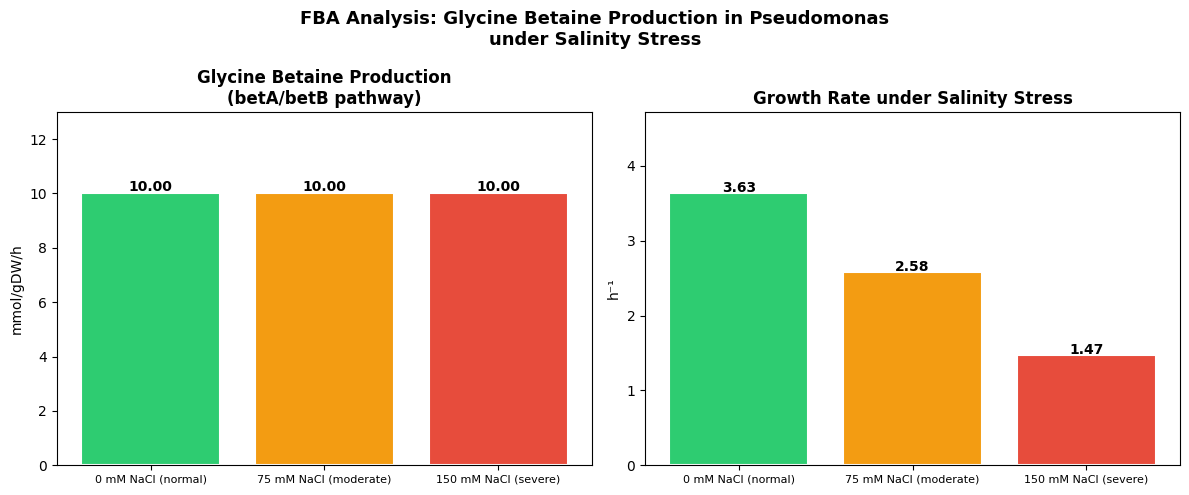

✅ Figure saved


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "FBA Analysis: Glycine Betaine Production in Pseudomonas\nunder Salinity Stress",
    fontsize=13,
    fontweight="bold"
)

# Extract values
conditions = [r["Condition"] for r in results]

glyb_vals = [
    r["Glycine betaine (mmol/gDW/h)"]
    for r in results
]

growth_vals = [
    r["Growth rate (h⁻¹)"]
    for r in results
]

colors = ["#2ecc71", "#f39c12", "#e74c3c"]

# Plot 1 — Glycine betaine production
bars1 = ax1.bar(
    conditions,
    glyb_vals,
    color=colors,
    edgecolor="white",
    linewidth=1.5
)

ax1.set_title(
    "Glycine Betaine Production\n(betA/betB pathway)",
    fontweight="bold"
)

ax1.set_ylabel("mmol/gDW/h")

ax1.set_ylim(0, max(glyb_vals) * 1.3)

for bar, val in zip(bars1, glyb_vals):

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{val:.2f}",
        ha="center",
        fontweight="bold"
    )

ax1.tick_params(axis="x", labelsize=8)

# Plot 2 — Growth rate
bars2 = ax2.bar(
    conditions,
    growth_vals,
    color=colors,
    edgecolor="white",
    linewidth=1.5
)

ax2.set_title(
    "Growth Rate under Salinity Stress",
    fontweight="bold"
)

ax2.set_ylabel("h⁻¹")

ax2.set_ylim(0, max(growth_vals) * 1.3)

for bar, val in zip(bars2, growth_vals):

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center",
        fontweight="bold"
    )

ax2.tick_params(axis="x", labelsize=8)

# Save figure
plt.tight_layout()

plt.savefig(
    "FBA_glycine_betaine_salinity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved")